# **Statistical Analysis on Synthetic Dataset** 

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

## Step 2: Create the Dataset

In [4]:
# create the random seed for reproducibility
np.random.seed(42)

# create synthetic dataset
data = {
    'product_id': range(1, 21),
    'product_name': [f'Product{i}' for i in range(1, 21)],
    'category': np.random.choice(['Electronics', 'Clothings', 'Home', 'Sports'], 20),
    'units_sold': np.random.poisson(lam=20, size=20), # poisson dist for sales
    'sale_date': pd.date_range(start = '2025-12-01', periods=20, freq='D')
}

sales_data = pd.DataFrame(data)

print("Sales Data:")
print(sales_data)

Sales Data:
    product_id product_name     category  units_sold  sale_date
0            1     Product1         Home          25 2025-12-01
1            2     Product2       Sports          15 2025-12-02
2            3     Product3  Electronics          17 2025-12-03
3            4     Product4         Home          19 2025-12-04
4            5     Product5         Home          21 2025-12-05
5            6     Product6       Sports          17 2025-12-06
6            7     Product7  Electronics          19 2025-12-07
7            8     Product8  Electronics          16 2025-12-08
8            9     Product9         Home          21 2025-12-09
9           10    Product10    Clothings          21 2025-12-10
10          11    Product11         Home          17 2025-12-11
11          12    Product12         Home          22 2025-12-12
12          13    Product13         Home          14 2025-12-13
13          14    Product14         Home          17 2025-12-14
14          15    Product15 

In [5]:
# Save the dataFrame as csv file 
sales_data.to_csv('sales_data', index=False)

In [6]:
# path location
import os
os.getcwd()

'C:\\Users\\akash\\STATISTICS'

## Step 3: Descriptive Statistics

In [9]:
# decriptive statistics is work only on numbers so,
# 'units_sold' column is selected for descriptive stats

descriptive_stats = sales_data['units_sold'].describe()
print("\nDecriptive statistics for units sold:")
print(descriptive_stats)

# Additional statistics 
mean_sale = sales_data['units_sold'].mean()
median_sale = sales_data['units_sold'].median()
mode_sale = sales_data['units_sold'].mode()[0]
variance_sale = sales_data['units_sold'].var()
std_deviation_sale = sales_data['units_sold'].std()

# Grouping by Category and calculate total and avg
category_stats = sales_data.groupby('category')['units_sold'].agg(['sum', 'mean', 'std']).reset_index()
category_stats.columns = ['Category', 'Total Units Sold', 'Average Units Sold', 'Std Dev of Units Sold']

# Display the results
print("\nStatistical Analysis:")
print(f"Mean Units Sold: {mean_sale}")
print(f"Median Units Sold: {median_sale}")
print(f"Mode Units Sold: {mode_sale}")
print(f"Variance Units Sold: {variance_sale}")
print(f"Standard Deviation Units Sold: {std_deviation_sale}")

print("\nCategory Statistics:")
print(category_stats)


Decriptive statistics for units sold:
count    20.000000
mean     18.800000
std       3.302312
min      13.000000
25%      17.000000
50%      18.500000
75%      21.000000
max      25.000000
Name: units_sold, dtype: float64

Statistical Analysis:
Mean Units Sold: 18.8
Median Units Sold: 18.5
Mode Units Sold: 17
Variance Units Sold: 10.90526315789474
Standard Deviation Units Sold: 3.3023117899275864

Category Statistics:
      Category  Total Units Sold  Average Units Sold  Std Dev of Units Sold
0    Clothings                21           21.000000                    NaN
1  Electronics                73           18.250000               2.217356
2         Home               181           20.111111               3.723051
3       Sports               101           16.833333               2.714160


## Step 4: Inferential Statistics

In [11]:
# confidence Interval of the mean of units sold
confidence_level = 0.95
degree_freedom = len(sales_data['units_sold']) - 1
sample_mean = mean_sale
sample_standard_error = std_deviation_sale/np.sqrt(len(sales_data['units_sold']))

# t-score for confidence level
t_score = stats.t.ppf((1 + confidence_level)/ 2, degree_freedom)
margin_of_error = t_score * sample_standard_error

confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print("\nConfidence Interval for the mean of Units Sold:")
print(confidence_interval)


Confidence Interval for the mean of Units Sold:
(np.float64(17.254470507823573), np.float64(20.34552949217643))


## Hypothesis Testing

In [12]:
# Hypothesis Testing (t-test)
# Null hypothesis: Mean units sold is equal to 20
# Alternative hypothesis: Mean units sold is not equal to 20

t_statistic, p_value = stats.ttest_1samp(sales_data['units_sold'], 20)

print("\nHypothesis Testing (t-test):")
print(f"T-statistic: {t_statistic}, P-value: {p_value}")

if p_value < 0.05:
    print("Reject the Null Hypothesis: The Mean units sold is sigficantly differnt from 20")
else:
    print("Fail to Reject the Null Hypothesis: The mean units sold is not sigficantly different from 20")


Hypothesis Testing (t-test):
T-statistic: -1.6250928099424466, P-value: 0.12061572226781002
Fail to Reject the Null Hypothesis: The mean units sold is not sigficantly different from 20


## Step 5: Visualizations

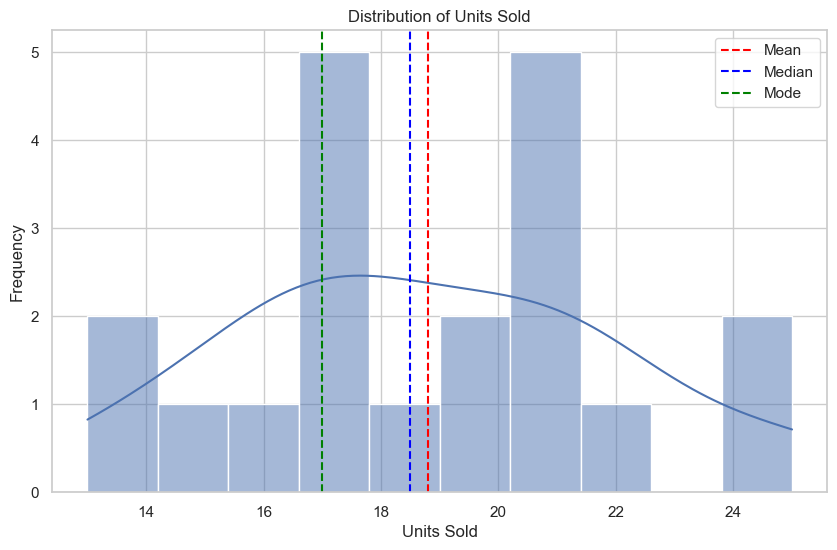

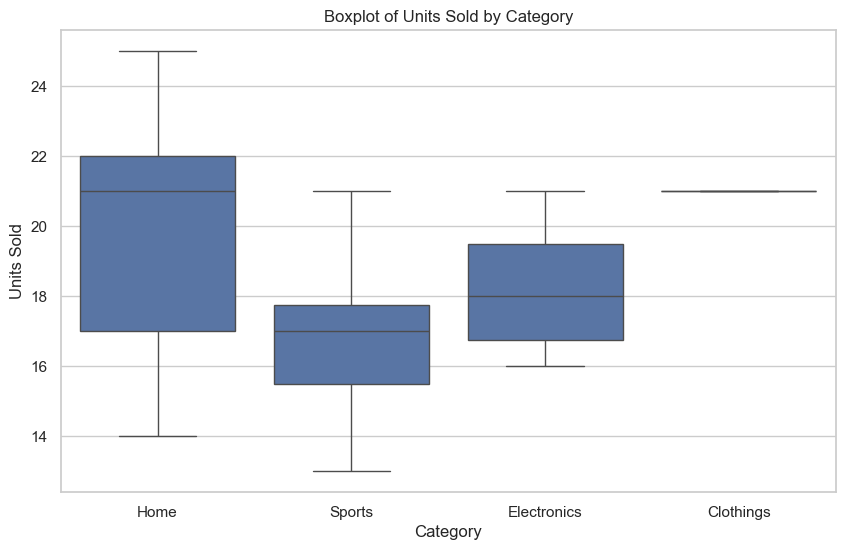

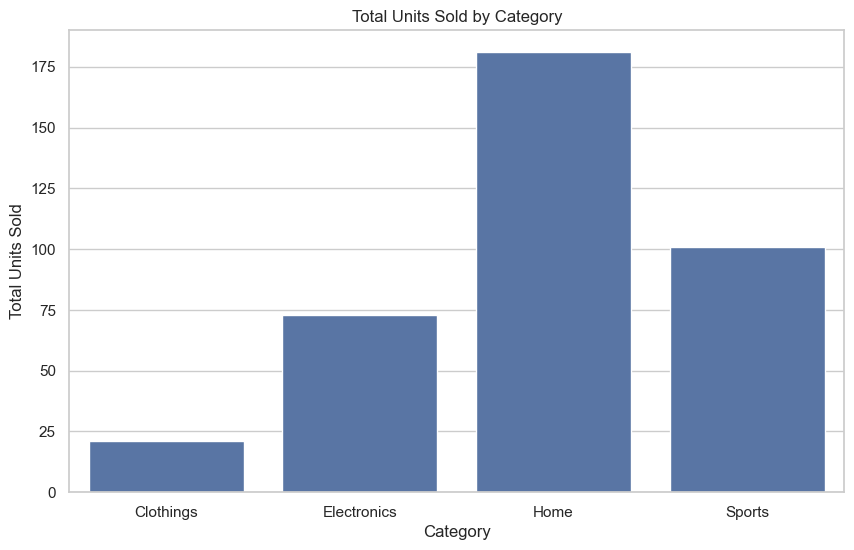

In [13]:
# Visualizations
sns.set(style="whitegrid")

# Plot distribution of units sold
plt.figure(figsize=(10, 6))
sns.histplot(sales_data['units_sold'], bins=10, kde=True)
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.axvline(mean_sale, color='red', linestyle='--', label='Mean')
plt.axvline(median_sale, color='blue', linestyle='--', label='Median')
plt.axvline(mode_sale, color='green', linestyle='--', label='Mode')
plt.legend()
plt.show()

# Boxplot for units sold by category
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='units_sold', data=sales_data)
plt.title('Boxplot of Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Units Sold')
plt.show()

# Bar plot for total units sold by category
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Total Units Sold', data=category_stats)
plt.title('Total Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.show()
